###Importing Modules

In [2]:
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

###Task0: Dataset

In [6]:
names = [
"Aarav","Aarya","Aadhya","Aaditya","Aakash","Aarushi","Aditi","Aditya","Aisha","Akash",
"Akshara","Aman","Amrita","Ananya","Anika","Anil","Anirudh","Anisha","Anjali","Ankit",
"Ansh","Anshika","Anshul","Anu","Anurag","Anusha","Arjun","Arnav","Arpita","Arya",
"Ashish","Ashwin","Avani","Ayaan","Ayush","Ayushi","Bhavya","Chaitanya","Charu","Dev",
"Devansh","Devika","Dhruv","Diya","Divya","Gaurav","Gayatri","Harsh","Ishaan","Isha",
"Ishita","Jai","Janvi","Jatin","Jaya","Karan","Kavya","Krishna","Lakshmi","Manav",
"Meera","Mohan","Naina","Nikhil","Nisha","Om","Parth","Pooja","Pranav","Priya",
"Raghav","Rahul","Raj","Rani","Riya","Rohan","Roshni","Saanvi","Sachin","Sagar",
"Saloni","Samarth","Sanjay","Sanya","Sarika","Shiv","Shivani","Shruti","Siddharth","Simran",
"Sneha","Soham","Sonali","Sourabh","Sudhir","Suman","Suraj","Swati","Tanvi","Tarun",
"Trisha","Uday","Uma","Varun","Vedant","Vikas","Vinay","Vivek","Yash","Yogesh","Zoya","Abhay", "Aditi", "Akash", "Amrit", "Anant", "Anjali", "Anshul", "Archit", "Ashwini", "Avik",
    "Balvir", "Barkha", "Bhaven", "Bindia", "Chandan", "Chetna", "Darpan", "Deven", "Dharam", "Diksha",
    "Eshan", "Ekta", "Gagan", "Geet", "Girik", "Gunjan", "Hardik", "Himani", "Inesh", "Ishita",
    "Jatin", "Jiya", "Kailash", "Kanika", "Keshav", "Kinjal", "Kunsh", "Lavanya", "Madan", "Malini",
    "Manan", "Mansi", "Mayank", "Mihir", "Monali", "Mridul", "Muskan", "Nalin", "Nandini", "Naveen",
    "Neetu", "Nihal", "Nimai", "Nishad", "Niyati", "Ojas", "Omna", "Pahal", "Palak", "Pankhuri",
    "Pavani", "Pranay", "Prisha", "Purvi", "Rachit", "Radhe", "Rajat", "Rakshit", "Rashi", "Ridhi",
    "Ronak", "Rupal", "Sagar", "Saloni", "Sameer", "Sanjana", "Sarthak", "Seema", "Shaan", "Shikha",
    "Shlok", "Shubh", "Smita", "Somya", "Suhani", "Sumit", "Swati", "Tanay", "Tripti", "Udai",
    "Unnati", "Urvashi", "Utkarsh", "Vaidehi", "Vansh", "Vihan", "Viral", "Vrinda", "Vyom", "Yamir",
    "Yatin", "Yukta", "Yuva", "Zaara", "Abhijit", "Adhir", "Advitya", "Ajit", "Alok", "Ambar",
    "Amit", "Amol", "Animesh", "Anirudh", "Ankur", "Ansh", "Anuj", "Apurva", "Arpit", "Ashish",
    "Ashok", "Atul", "Avinash", "Ayush", "Balram", "Bharat", "Bhupen", "Binay", "Brijesh", "Chaitanya",
    "Chandresh", "Chinmay", "Darshan", "Deepak", "Deependra", "Devansh", "Dhananjay", "Dinesh", "Divit", "Ekansh",
    "Eshwar", "Gaurang", "Gautam", "Girish", "Gulshan", "Harshil", "Hemang", "Hriday", "Inder", "Jagat",
    "Jaideep", "Janak", "Jayant", "Jitendra", "Jivraj", "Jyotir", "Kalpit", "Kamal", "Kanan", "Kapil",
    "Kavi", "Ketan", "Kirit", "Kuldeep", "Kush", "Lakshay", "Lalit", "Lochan", "Madhur", "Mahendra",
    "Malay", "Manas", "Manish", "Manmeet", "Manoj", "Mayur", "Milap", "Mitul", "Mohit", "Mrigesh",
    "Mudit", "Mukul", "Naman", "Narendra", "Navin", "Neeraj", "Nihar", "Nilay", "Nirmal", "Nishant",
    "Nitish", "Ojas", "Padam", "Pallav", "Paresh", "Piyush", "Prabhat", "Pradeep", "Prafull", "Pramod",
    "Pranay", "Prashant", "Prateek", "Pratyush", "Praveen", "Puneet", "Purushottam", "Raghu", "Rajendra", "Rajesh",
    "Rakesh", "Ram", "Raman", "Ranbir", "Ranjeet", "Ratul", "Ravi", "Rishabh", "Ritesh", "Ronit",
    "Rupesh", "Sachin", "Sahil", "Saket", "Sambit", "Sandeep", "Sanjay", "Sanjeev", "Santosh", "Saral",
    "Saurabh", "Shailendra", "Shakti", "Sharad", "Shashank", "Shekhar", "Shishir", "Shreyas", "Siddhant", "Somesh",
    "Sparsh", "Subodh", "Sudhir", "Suhas", "Sumit", "Sunil", "Suraj", "Sushant", "Suyash", "Tapan",
    "Tarun", "Tejas", "Trilok", "Uday", "Ujjwal", "Umang", "Upesh", "Utkarsh", "Vaibhav", "Varun",
    "Vedant", "Vibhu", "Vidit", "Vijay", "Vikas", "Vikram", "Vimal", "Vinay", "Vineet", "Vipul",
    "Vishal", "Vishwas", "Vivek", "Vyom", "Yadunath", "Yash", "Yogesh", "Yudhisthir","Aarav", "Ishani", "Arjun", "Ananya", "Vihaan", "Meera", "Rohan", "Kavya", "Sai", "Priyanka",
    "Aditya", "Zara", "Reyansh", "Myra", "Krishna", "Diya", "Aryan", "Anika", "Ishaan", "Sana",
    "Kabir", "Tanvi", "Advait", "Riya", "Vivaan", "Kyra", "Atharv", "Navya", "Shaurya", "Isha",
    "Rudra", "Zoya", "Veer", "Avni", "Ayaan", "Trisha", "Laksh", "Amara", "Dhruv", "Myra",
    "Parth", "Sara", "Ranveer", "Kiara", "Yuvan", "Aisha", "Dev", "Inaya", "Rishi", "Vedika",
    "Siddharth", "Prisha", "Agastya", "Shanaya", "Omkar", "Hazel", "Vikram", "Tara", "Raghav", "Nora",
    "Yash", "Gauri", "Nakul", "Bhavna", "Madhav", "Jhanvi", "Kartik", "Shivani", "Daksh", "Amrita",
    "Samrat", "Pooja", "Manikandan", "Shruti", "Abhimanyu", "Lekha", "Tushar", "Vidya", "Chirag", "Nehal",
    "Varun", "Sneha", "Ganesh", "Alisha", "Harish", "Komal", "Sunil", "Padmini", "Pranav", "Shaila",
    "Milind", "Gayatri", "Chetan", "Namrata", "Arvind", "Mallika", "Suresh", "Deepa", "Anil", "Rekha","Aarav", "Aarya", "Aadhya", "Aaditya", "Aakash", "Aarushi", "Aditi", "Aditya", "Aisha", "Akash",
    "Akshara", "Aman", "Amrita", "Ananya", "Anika", "Anil", "Anirudh", "Anisha", "Anjali", "Ankit",
    "Ansh", "Anshika", "Anshul", "Anu", "Anurag", "Anusha", "Arjun", "Arnav", "Arpita", "Arya",
    "Ashish", "Ashwin", "Avani", "Ayaan", "Ayush", "Ayushi", "Bhavya", "Chaitanya", "Charu", "Dev",
    "Devansh", "Devika", "Dhruv", "Diya", "Divya", "Gaurav", "Gayatri", "Harsh", "Ishaan", "Isha",
    "Ishita", "Jai", "Janvi", "Jatin", "Jaya", "Karan", "Kavya", "Krishna", "Lakshmi", "Manav",
    "Meera", "Mohan", "Naina", "Nikhil", "Nisha", "Om", "Parth", "Pooja", "Pranav", "Priya",
    "Raghav", "Rahul", "Raj", "Rani", "Riya", "Rohan", "Roshni", "Saanvi", "Sachin", "Sagar",
    "Saloni", "Samarth", "Sanjay", "Sanya", "Sarika", "Shiv", "Shivani", "Shruti", "Siddharth", "Simran",
    "Sneha", "Soham", "Sonali", "Sourabh", "Sudhir", "Suman", "Suraj", "Swati", "Tanvi", "Tarun",
    "Trisha", "Uday", "Uma", "Varun", "Vedant", "Vikas", "Vinay", "Vivek", "Yash", "Yogesh", "Zoya",
    "Abhay", "Amrit", "Anant", "Archit", "Ashwini", "Avik", "Balvir", "Barkha", "Bhaven", "Bindia",
    "Chandan", "Chetna", "Darpan", "Deven", "Dharam", "Diksha", "Eshan", "Ekta", "Gagan", "Geet",
    "Girik", "Gunjan", "Hardik", "Himani", "Inesh", "Kailash", "Kanika", "Keshav", "Kinjal", "Kunsh",
    "Lavanya", "Madan", "Malini", "Manan", "Mansi", "Mayank", "Mihir", "Monali", "Mridul", "Muskan",
    "Nalin", "Nandini", "Naveen", "Neetu", "Nihal", "Nimai", "Nishad", "Niyati", "Ojas", "Omna",
    "Pahal", "Palak", "Pankhuri", "Pavani", "Pranay", "Prisha", "Purvi", "Rachit", "Radhe", "Rajat",
    "Rakshit", "Rashi", "Ridhi", "Ronak", "Rupal", "Sameer", "Sanjana", "Sarthak", "Seema", "Shaan",
    "Shikha", "Shlok", "Shubh", "Smita", "Somya", "Suhani", "Sumit", "Tanay", "Tripti", "Unnati",
    "Urvashi", "Utkarsh", "Vaidehi", "Vansh", "Vihan", "Viral", "Vrinda", "Vyom", "Yamir", "Yatin",
    "Yukta", "Yuva", "Zaara", "Abhijit", "Adhir", "Advitya", "Ajit", "Alok", "Ambar", "Amit", "Amol",
    "Animesh", "Ankur", "Anuj", "Apurva", "Arpit", "Ashok", "Atul", "Avinash", "Balram", "Bharat",
    "Bhupen", "Binay", "Brijesh", "Chandresh", "Chinmay", "Darshan", "Deepak", "Deependra", "Dhananjay",
    "Dinesh", "Divit", "Ekansh", "Eshwar", "Gaurang", "Gautam", "Girish", "Gulshan", "Harshil", "Hemang",
    "Hriday", "Inder", "Jagat", "Jaideep", "Janak", "Jayant", "Jitendra", "Jivraj", "Jyotir", "Kalpit",
    "Kamal", "Kanan", "Kapil", "Kavi", "Ketan", "Kirit", "Kuldeep", "Kush", "Lakshay", "Lalit", "Lochan",
    "Madhur", "Mahendra", "Malay", "Manas", "Manish", "Manmeet", "Manoj", "Mayur", "Milap", "Mitul",
    "Mohit", "Mrigesh", "Mudit", "Mukul", "Naman", "Narendra", "Navin", "Neeraj", "Nihar", "Nilay",
    "Nirmal", "Nishant", "Nitish", "Padam", "Pallav", "Paresh", "Piyush", "Prabhat", "Pradeep", "Prafull",
    "Pramod", "Prashant", "Prateek", "Pratyush", "Praveen", "Puneet", "Purushottam", "Raghu", "Rajendra",
    "Rajesh", "Rakesh", "Ram", "Raman", "Ranbir", "Ranjeet", "Ratul", "Ravi", "Rishabh", "Ritesh",
    "Ronit", "Rupesh", "Sachin", "Sahil", "Saket", "Sambit", "Sandeep", "Sanjay", "Sanjeev", "Santosh",
    "Saral", "Saurabh", "Shailendra", "Shakti", "Sharad", "Shashank", "Shekhar", "Shishir", "Shreyas",
    "Somesh", "Sparsh", "Subodh", "Sudhir", "Suhas", "Suraj", "Sushant", "Suyash", "Tapan", "Tarun",
    "Tejas", "Trilok", "Ujjwal", "Umang", "Upesh", "Vaibhav", "Vibhu", "Vidit", "Vijay", "Vimal",
    "Vinay", "Vineet", "Vipul", "Vishal", "Vishwas", "Yadunath", "Yudhisthir", "Aabha", "Aahna", "Aamani",
    "Aaradhya", "Aatish", "Abhibhava", "Abhijay", "Abhinand", "Abhinav", "Abhiram", "Abhishikta", "Abhivira",
    "Achintya", "Adah", "Adarsh", "Adhrit", "Aditri", "Advay", "Advika", "Agastya", "Ahana", "Ahilya",
    "Aishani", "Ajay", "Akshaj", "Akshat", "Akshaya", "Akshita", "Alaknanda", "Alok", "Amala", "Amara",
    "Amay", "Ambar", "Amishi", "Amoli", "Amulya", "Anagha", "Anala", "Anand", "Anandi", "Anant",
    "Anila", "Anirvan", "Anjika", "Anjuli", "Ankit", "Ankur", "Anoma", "Anshum", "Ansuya", "Anugraha",
    "Anura", "Anuvrat", "Anvitha", "Aparna", "Apsara", "Apurva", "Aradhana", "Archa", "Arghya", "Arha",
    "Arhat", "Arihant", "Arindam", "Arista", "Arjit", "Arka", "Arpana", "Arunika", "Arunima", "Arush",
    "Arvinda", "Aryaman", "Asavari", "Asheem", "Ashita", "Ashoka", "Ashray", "Asmita", "Atasi", "Atman",
    "Atreyi", "Atulya", "Avadhuta", "Avanindra", "Avasa", "Avishi", "Avit", "Avyukta", "Ayati", "Ayushree",
    "Bageshri", "Bakul", "Bala", "Balamani", "Banhi", "Banshi", "Bela", "Bhadra", "Bhagirath", "Bhagwan",
    "Bhairavi", "Bhakti", "Bhalendra", "Bhanu", "Bhanumati", "Bharat", "Bharati", "Bhargav", "Bhaswati",
    "Bhavesh", "Bhawna", "Bhibhuti", "Bhim", "Bhishma", "Bhooma", "Bhoomi", "Bhoomika", "Bhupesh",
    "Bhuvan", "Bhuvi", "Bijay", "Bimal", "Bina", "Binita", "Biren", "Bodhi", "Brahma", "Bratati",
    "Brij", "Brijesh", "Budhil", "Cauvery", "Chaitali", "Chakor", "Chakradhar", "Chakrika", "Chameli",
    "Champa", "Chanakya", "Chanchal", "Chand", "Chanda", "Chandani", "Chandika", "Chandini", "Chandra",
    "Chandrak", "Chandramohan", "Chandran", "Chandrani", "Chandranshu", "Chandrasen", "Chandrashekhar",
    "Chandresh", "Charan", "Charitra", "Charu", "Charulata", "Charuvrat", "Chatura", "Chetan", "Chetana",
    "Chhavi", "Chhavvi", "Chhaya", "Chidambar", "Chinmay", "Chinmayi", "Chintan", "Chintanika", "Chitra",
    "Chitraksh", "Chitralekha", "Chitran", "Chitrangada", "Chitrarath", "Chitresh", "Chitrita", "Chuda",
    "Dadhichi", "Daksh", "Daksha", "Dakshata", "Dakshina", "Daman", "Damini", "Darika", "Darpak",
    "Darpan", "Darpana", "Darsh", "Darsha", "Darshak", "Darshan", "Darshana", "Darshani", "Darshat",
    "Darshwana", "Daya", "Dayal", "Dayamayee", "Dayanand", "Dayanidhi", "Dayasagar", "Dayaswarup",
    "Deeba", "Deep", "Deepa", "Deepak", "Deepakala", "Deepali", "Deepan", "Deepanjali", "Deepankar",
    "Deepanshu", "Deepavati", "Deepika", "Deepinder", "Deepit", "Deepshikha", "Deeptanshu", "Deepti",
    "Deeptika", "Deeptiman", "Deeptimoy", "Deeptimoyee", "Dev", "Deva", "Devaj", "Devak", "Devaki",
    "Devakumar", "Deval", "Devanand", "Devang", "Devangana", "Devangi", "Devani", "Devansh", "Devanshi",
    "Devarsi", "Devarya", "Devasish", "Devasmita", "Devavrat", "Devendra", "Devi", "Devika", "Devina",
    "Devishi", "Devjani", "Devjyoti", "Devkumar", "Devvrat", "Dhanalakshmi", "Dhananad", "Dhananjay",
    "Dhanesh", "Dhanraj", "Dhanshree", "Dhanush", "Dhanvant", "Dhanvi", "Dhanvin", "Dhanya", "Dhara",
    "Dharan", "Dharani", "Dharini", "Dharma", "Dharmendra", "Dharmesh", "Dharmik", "Dharmistha", "Dharnidhar",
    "Dharti", "Dhaval", "Dhavit", "Dheeman", "Dheemant", "Dheer", "Dheera", "Dheeraj", "Dheeran",
    "Dheeti", "Dhinant", "Dhir", "Dhira", "Dhiraj", "Dhisha", "Dhitika", "Dhriti", "Dhritiman", "Dhriv",
    "Dhrupad", "Dhruv", "Dhruva", "Dhruvi", "Dhulan", "Dhvani", "Dhvany", "Dhyan", "Dhyana", "Dhyanesh",
    "Digambar", "Digant", "Diksha", "Dilip", "Dina", "Dinakar", "Dinanath", "Dinesh", "Dinkar", "Dipak",
    "Dipali", "Dipankar", "Dipanshu", "Dipti", "Disha", "Dishant", "Dishari", "Dishita", "Diti",
    "Divit", "Divya", "Divyaksh", "Divyanshu", "Divyendu", "Divyesh", "Doyel", "Draupadi", "Drona",
    "Drupad", "Dulari", "Durga", "Durgesh", "Durjay", "Durva", "Dushyant", "Dwaipayan", "Dwarka",
    "Dwarkadhish", "Dwarkanath", "Dwij", "Dwijendra", "Dwijesh", "Dyumna", "Dyuti", "Dyutiman", "Ecchumati",
    "Edha", "Eeshani", "Eeshwar", "Eila", "Eira", "Eka", "Ekagrata", "Ekaksha", "Ekaleer", "Ekant",
    "Ekansh", "Ekaparana", "Ekatma", "Ekavir", "Ekavira", "Ekayavan", "Ekhit", "Ekisha", "Ekshika",
    "Ekta", "Ektana", "Ela", "Elina", "Emani", "Enakshi", "Eshana", "Eshani", "Eshant", "Eshas",
    "Eshwar", "Eshwari", "Eshwarpreet", "Eshwin", "Eta", "Etash", "Eti", "Ezhil", "Faalgun", "Falguni",
    "Fanindra", "Fanish", "Fanishwar", "Farhad", "Fariha", "Farman", "Farrah", "Fateh", "Fatik",
    "Firoza", "Foolan", "Fulki", "Fullara", "Gagan", "Gagandeep", "Gaganvihari", "Gajanan", "Gajendra",
    "Gajpati", "Gajrup", "Gambhira", "Ganaka", "Ganapati", "Gandhi", "Gandhik", "Gandhini", "Ganesh",
    "Gangadhar", "Gangadutt", "Gangesh", "Gangeya", "Gangika", "Gangit", "Gangotri", "Ganjan", "Gara",
    "Gargi", "Garima", "Garjan", "Garud", "Gatita", "Gauhar", "Gaura", "Gaurang", "Gaurangi", "Gaurav",
    "Gauri", "Gaurika", "Gaurinath", "Gaurishankar", "Gautam", "Gautami", "Gaveshan", "Gaveshin", "Gavisht",
    "Gaya", "Gayak", "Gayan", "Gayatri", "Geet", "Geeta", "Geetali", "Geetanjali", "Geetika", "Geshna",
    "Ghalib", "Ghanshyam", "Ghoshal", "Giaan", "Giaandeep", "Girdhari", "Giri", "Giridhar", "Girija",
    "Girijapati", "Girilal", "Girimohan", "Girinath", "Girindra", "Girish", "Girishankar", "Girivar",
    "Gitanjali", "Givansh", "Gnyana", "Godavari", "Gokul", "Gopal", "Gopali", "Gopan", "Gopi",
    "Gopika", "Gopinath", "Gora", "Gorakhnath", "Goral", "Goswamee", "Gourab", "Goutam", "Govardhan",
    "Govind", "Govinda", "Gowri", "Grishma", "Gudakesha", "Gul", "Gulab", "Gulal", "Gulika", "Gulshan",
    "Gulzar", "Gunagya", "Gunaja", "Gunakar", "Gunal", "Gunamay", "Gunanidhi", "Gunasagar", "Gunashekhar",
    "Gunav", "Gunbir", "Gunj", "Gunjan", "Gunjit", "Gunvansh", "Gunvant", "Gunvati", "Gunwanti", "Gurbachan",
    "Gurbani", "Gurdeep", "Gurdev", "Gurmukh", "Gurnam", "Gurpreet", "Gursharan", "Guru", "Gurudas",
    "Gurudutt", "Haimi", "Hamsa", "Hamsini", "Hansa", "Hanshal", "Hanshika", "Hansini", "Hanuman",
    "Hardik", "Harekrishna", "Harendra", "Haresh", "Hari", "Haricharan", "Haridas", "Harigopal", "Harihar",
    "Harij", "Harikrishna", "Harilal", "Harimanti", "Harinarayan", "Harinder", "Hariprasad", "Haripriya",
    "Hariram", "Harish", "Harishankar", "Harit", "Harivansh", "Harivilas", "Harjas", "Harjit", "Harkesh",
    "Harman", "Harmeen", "Harneet", "Harpal", "Harpreet", "Harsh", "Harsha", "Harshad", "Harshal",
    "Harshini", "Harshita", "Harshul", "Harshvardhan", "Harsita", "Hasmukh", "Hastha", "Hasumati", "Heera",
    "Heerak", "Hem", "Hema", "Hemadri", "Hemal", "Hemang", "Hemangi", "Hemani", "Hemant", "Hemanti",
    "Hemaprabha", "Hemashri", "Hemendra", "Hemlata", "Hemraj", "Heramba", "Hetal", "Himaja", "Himalaya",
    "Himani", "Himanshu", "Himmat", "Hina", "Hindola", "Hiral", "Hiran", "Hiranmay", "Hiranmayi",
    "Hiranya", "Hirendra", "Hiresh", "Hitendra", "Hitesh", "Hiya", "Holika", "Homa", "Homesh",
    "Hradini", "Hridaya", "Hridayanath", "Hridayesh", "Hridyanshu", "Hrishikesh", "Hritik", "Huda", "Humaila"

]

# Ensure we have exactly 1000 names (unique ones from the list)
final_names = list(set(names)) # Remove any accidental duplicates
random.shuffle(final_names)

with open("TrainingNames.txt","w") as f:
    for name in final_names:
        f.write(name + "\n")

###Building Vocab

In [7]:
def build_vocab(words):
  # creates a sorted set of all unique characters appearing in all names
    chars = sorted(list(set("".join(words)))) + ['.']

    # maps char to index
    stoi = {s:i for i,s in enumerate(chars)}
    # maps index to character
    itos = {i:s for s,i in stoi.items()}
    return chars, stoi, itos

In [8]:
def encode_words(words, stoi):
    data = []

    for w in words:
       # map every character to its index and append '.' as end token
        seq = [stoi[c] for c in w] + [stoi['.']]
        data.append(seq)
    return data

In [9]:
words = [w.strip().lower() for w in open("TrainingNames.txt")]

chars, stoi, itos = build_vocab(words)
data = encode_words(words, stoi)

vocab_size = len(chars)
print("Vocab Size: ", vocab_size)

Vocab Size:  25


In [10]:
print(chars)

['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'w', 'y', 'z', '.']


In [11]:
print(data[0])

[7, 16, 8, 3, 0, 22, 24]


###Training Function

In [12]:
def train_model(model, data, stoi, epochs=30, lr=0.003):
    # loss function for multi-class character prediction
    criterion = nn.CrossEntropyLoss()

    # optimizer to update model parameters
    optimizer = optim.Adam(model.parameters(), lr=lr)
    epoch_losses=[]

    for epoch in range(epochs):
        total_loss = 0

        # iterate over each word
        for word in data:
            loss = 0

            # reset gradients before processing new word
            model.zero_grad()

            # initialize hidden state at start of each sequence
            if hasattr(model, "init_hidden"): hidden = model.init_hidden()

            # store previous hidden states (used only for attention model)
            prev_states = []

            # inputs: start token + all chars except last
            inputs = [stoi['.']] + word[:-1]

            # targets: actual characters including end token
            targets = word

            # iterate through characters of the word
            for i, t in zip(inputs, targets):

                # create one-hot vector for current character
                x = torch.zeros(1, model.vocab_size)
                x[0][i] = 1

                # if model is attention-based, pass previous states
                if model.__class__.__name__ == "RNNAttention":
                    out, hidden = model(x, hidden, prev_states)

                    # store hidden state for future attention
                    prev_states.append(hidden)
                else:
                    # normal RNN / BLSTM forward pass
                    out, hidden = model(x, hidden)

                # compute loss between predicted char and target char
                loss += criterion(out, torch.tensor([t]))

            # backpropagation
            loss.backward()

            # update model parameters
            optimizer.step()

            # accumulate loss
            total_loss += loss.item()

        avg_loss = total_loss / len(data)
        epoch_losses.append(avg_loss)   # store loss

        print(f"Epoch {epoch+1}: {avg_loss:.4f}")
    return epoch_losses

###Generate name using trained model

In [13]:
def generate_name(model, stoi, itos, max_len=20):
    # initialize hidden state
    hidden = model.init_hidden()

    # store previous hidden states (used for attention model)
    prev_states = []

    # start input with start token '.'
    x = torch.zeros(1, model.vocab_size)
    x[0][stoi['.']] = 1

    # store generated characters
    name = ""

    for _ in range(max_len):

        # forward pass
        if model.__class__.__name__ == "RNNAttention":
            # attention model needs previous hidden states
            out, hidden = model(x, hidden, prev_states)
            prev_states.append(hidden)
        else:
            # vanilla RNN / BLSTM
            out, hidden = model(x, hidden)

        # convert logits to probabilities
        prob = torch.softmax(out, dim=1)

        # sample next character index from probability distribution
        idx = torch.multinomial(prob,1).item()

        # stop generation if end token '.' predicted
        if itos[idx] == '.':
            break

        # append predicted character to name
        name += itos[idx]

        # prepare next input as one-hot vector of predicted char
        x = torch.zeros(1, model.vocab_size)
        x[0][idx] = 1

    # return generated name
    return name

###Vanilla RNN

In [14]:
class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.vocab_size = vocab_size #vocab size
        self.hidden_size = hidden_size # size of hidden vector

        # input-to-hidden layer: takes concatenated [input + previous hidden] |
        # outputs new hidden state
        self.i2h = nn.Linear(vocab_size + hidden_size, hidden_size)

        #hidden to output layer: convert hidden state to next char score
        self.h2o = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, h):
      # combines input vector with the previous hidden state
        combined = torch.cat((x, h), 1)

        # computes new hidden state using tanh activation
        h = torch.tanh(self.i2h(combined))
        # compute output logits ie prob score for next char
        o = self.h2o(h)
        return o, h

    def init_hidden(self):
      # initialize hidden state to zero at the start of seq
        return torch.zeros(1, self.hidden_size)

In [15]:
rnn = VanillaRNN(vocab_size,128)
losses_rnn=train_model(rnn, data, stoi,epochs=30)

Epoch 1: 16.9583
Epoch 2: 15.6006
Epoch 3: 15.2879
Epoch 4: 15.0885
Epoch 5: 14.8758
Epoch 6: 14.7577
Epoch 7: 14.6161
Epoch 8: 14.4712
Epoch 9: 14.3484
Epoch 10: 14.1673
Epoch 11: 14.1863
Epoch 12: 14.1402
Epoch 13: 14.0501
Epoch 14: 14.0726
Epoch 15: 13.9059
Epoch 16: 13.8967
Epoch 17: 13.8468
Epoch 18: 13.7611
Epoch 19: 13.6960
Epoch 20: 13.6526
Epoch 21: 13.5323
Epoch 22: 13.7729
Epoch 23: 13.5742
Epoch 24: 13.5950
Epoch 25: 13.5861
Epoch 26: 13.4764
Epoch 27: 13.6394
Epoch 28: 13.6663
Epoch 29: 13.5983
Epoch 30: 13.6000


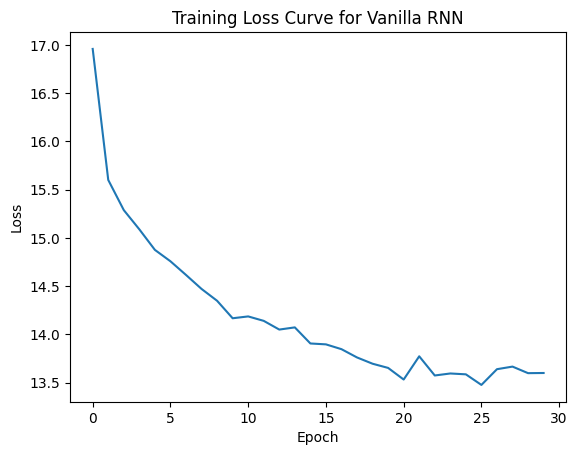

In [17]:
plt.plot(losses_rnn, label="Vanilla RNN")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve for Vanilla RNN")
plt.show()

In [18]:
name_gen_rnn = [generate_name(rnn, stoi, itos) for i in range(20)]

print("Generated Names by Vanilla RNN:")
for name in name_gen_rnn:
    print(name)

Generated Names by Vanilla RNN:
rahiti
forikamk
girish
gharsh
jau
ishastha
arush
dhfulhihi
karshv
darshant
harvi
herankayi
dreesh
dharij
saatis
sahyan
racosn
himandidhar
angom
sarjisha


In [19]:
generated_all = [generate_name(rnn, stoi, itos) for _ in range(1000)]

train_set = set(words)
unique_generated = set(generated_all)

novel_names_rnn = [name for name in unique_generated if name not in train_set]

In [20]:
print("\nGenerated Names not in training data(Vanilla RNN):")
for name in novel_names_rnn[:20]:
    print(name)


Generated Names not in training data(Vanilla RNN):

aksha
padysh
yuday
hanshansha
ganash
mraash
karas
faloshanka
govish
sanila
tashaa
vikra
davarusha
anindra
gani
hamsl
anith
dayirish
santav


###BLSTM

In [21]:
class BLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()

        # store vocabulary size and hidden dimension
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size

        # bidirectional LSTM layer
        # processes sequence in both forward and backward directions
        # input size = vocab_size (one-hot vector) | hidden size = hidden_size

        self.lstm = nn.LSTM(vocab_size, hidden_size, bidirectional=True)

        # fully connected layer
        # since BLSTM outputs hidden_size*2 (forward + backward); map it back to vocab size (next character prediction)

        self.fc = nn.Linear(hidden_size*2, vocab_size)

    def forward(self, x, h):
        # LSTM expects input shape (seq_len, batch, input_size)
        # current x is (batch, vocab_size), so add seq_len dimension
        x = x.unsqueeze(0)

        # pass through bidirectional LSTM
        out, h = self.lstm(x, h)

        # remove sequence dimension and map to output vocabulary
        out = self.fc(out.squeeze(0))

        # return logits and updated hidden state
        return out, h

    def init_hidden(self):
        # initialize hidden state and cell state with zeros
        # shape = (num_directions, batch, hidden_size)
        # num_directions = 2 because bidirectional
        return (torch.zeros(2,1,self.hidden_size),
                torch.zeros(2,1,self.hidden_size))

In [22]:
blstm = BLSTM(vocab_size,128)
losses_blstm=train_model(blstm, data, stoi)

Epoch 1: 16.3876
Epoch 2: 14.4713
Epoch 3: 13.6593
Epoch 4: 12.9384
Epoch 5: 12.1985
Epoch 6: 11.5009
Epoch 7: 10.7655
Epoch 8: 10.1278
Epoch 9: 9.5670
Epoch 10: 9.1110
Epoch 11: 8.8183
Epoch 12: 8.5940
Epoch 13: 8.3972
Epoch 14: 8.1514
Epoch 15: 7.8856
Epoch 16: 7.7508
Epoch 17: 7.7118
Epoch 18: 7.5636
Epoch 19: 7.5244
Epoch 20: 7.5074
Epoch 21: 7.4854
Epoch 22: 7.4013
Epoch 23: 7.2639
Epoch 24: 7.2309
Epoch 25: 7.2518
Epoch 26: 7.1890
Epoch 27: 7.2437
Epoch 28: 7.2779
Epoch 29: 7.2676
Epoch 30: 7.1974


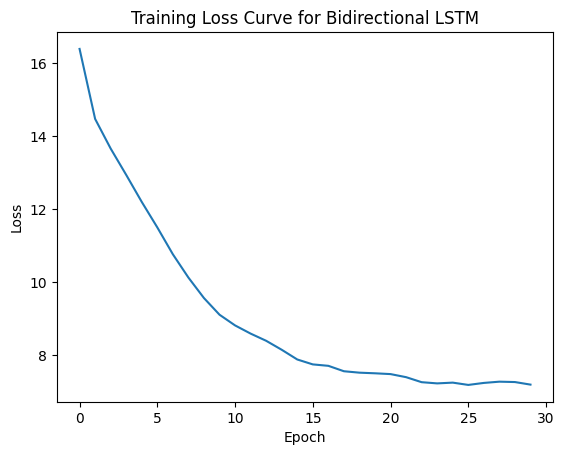

In [23]:
plt.plot(losses_blstm, label="BLSTM")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve for Bidirectional LSTM")
plt.show()

In [24]:
name_gen_blstm = [generate_name(blstm, stoi, itos) for i in range(20)]

print("Generated Names by Bi-directional LSTM:")
for name in name_gen_blstm:
    print(name)

Generated Names by Bi-directional LSTM:
riya
hriday
gaurishankar
chudak
darsh
lekha
chhaya
hastha
santosh
neeraj
mudil
harshvand
deveshan
eshas
devarsi
bina
gaurika
purushottam
chitran
eeshani


In [25]:
generated_all = [generate_name(blstm, stoi, itos) for _ in range(1000)]

train_set = set(words)
unique_generated = set(generated_all)

novel_names_blstm = [name for name in unique_generated if name not in train_set]

In [26]:
print("\nGenerated Names not in training data(Bi-directional LSTM):")
for name in novel_names_blstm[:20]:
    print(name)


Generated Names not in training data(Bi-directional LSTM):

gakatmesh
ashvanshu
greshma
nalok
paamok
sakta
sanjeet
ganadri
kapraf
etasi
praday
devanga
aarhant
avanindan
shakena
parkha
ahansh
yaten
gaganveep


###RNN with Basic Attention Mechanism

In [27]:
class RNNAttention(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()

        # store sizes
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size

        # computes next hidden state from input + previous hidden
        self.i2h = nn.Linear(vocab_size + hidden_size, hidden_size)

        # attention layer
        # takes [current hidden + previous hidden] and outputs attention score
        self.attn = nn.Linear(hidden_size*2, 1)

        # final output layer (context-> next char logits)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden, prev_states):

        # combine input character and previous hidden state
        combined = torch.cat((x, hidden), 1)

        # compute new hidden state
        hidden = torch.tanh(self.i2h(combined))

        # if no previous states exist
        if len(prev_states) == 0:
            context = hidden

        else:
            # compute attention scores with all previous hidden states
            scores = torch.stack([
                self.attn(torch.cat((hidden, h),1))
                for h in prev_states
            ])

            # flatten to 1D
            scores = scores.view(-1)

            # convert scores to probabilities
            weights = torch.softmax(scores, dim=0)

            # compute weighted sum of previous hidden states
            context = torch.zeros_like(hidden)
            for w,h in zip(weights, prev_states):
                context += w*h

        # use context vector to predict next character
        out = self.fc(context)

        return out, hidden

    def init_hidden(self):
        # initialize hidden state to zero
        return torch.zeros(1,self.hidden_size)

In [28]:
rnn_attn = RNNAttention(vocab_size,128)
losses_rnn_attn=train_model(rnn_attn, data, stoi)

Epoch 1: 19.2010
Epoch 2: 18.6785
Epoch 3: 18.4151
Epoch 4: 18.2929
Epoch 5: 18.1640
Epoch 6: 18.0537
Epoch 7: 17.9548
Epoch 8: 17.8254
Epoch 9: 17.7384
Epoch 10: 17.6707
Epoch 11: 17.5866
Epoch 12: 17.5352
Epoch 13: 17.5046
Epoch 14: 17.3684
Epoch 15: 17.3551
Epoch 16: 17.3351
Epoch 17: 17.4123
Epoch 18: 17.3325
Epoch 19: 17.3461
Epoch 20: 17.3165
Epoch 21: 17.3775
Epoch 22: 17.2785
Epoch 23: 17.2349
Epoch 24: 17.2160
Epoch 25: 17.2459
Epoch 26: 17.1478
Epoch 27: 17.3325
Epoch 28: 17.1608
Epoch 29: 17.2903
Epoch 30: 17.2965


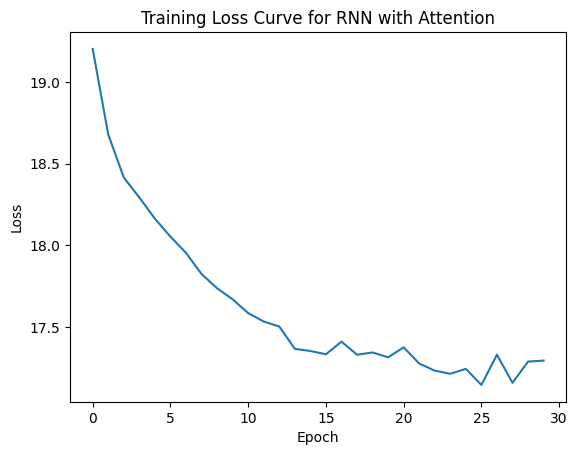

In [29]:
plt.plot(losses_rnn_attn, label="Rnn + Attention")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve for RNN with Attention")
plt.show()

In [30]:
name_gen_rnn_attn = [generate_name(rnn_attn, stoi, itos) for i in range(20)]

print("Generated Names by RNN with attention:")
for name in name_gen_rnn:
    print(name)

Generated Names by RNN with attention:
rahiti
forikamk
girish
gharsh
jau
ishastha
arush
dhfulhihi
karshv
darshant
harvi
herankayi
dreesh
dharij
saatis
sahyan
racosn
himandidhar
angom
sarjisha


In [31]:
generated_all = [generate_name(rnn, stoi, itos) for i in range(1000)]

train_set = set(words)
unique_generated = set(generated_all)

novel_names_rnn_attn = [name for name in unique_generated if name not in train_set]

In [32]:
print("\nGenerated Names not in training data(RNN with Attention):")
for name in novel_names_rnn_attn[0:20]:
    print(name)


Generated Names not in training data(RNN with Attention):
radhas

lakshamt
aitit
dhyanajh
furil
davar
cheerani
ojgwiba
ariru
aksish
suhaa
upsh
arushja
aabala
ekhish
dhaansi
govish
aruvam
faraz


###Task 2: Quantitative Evaluation

In [33]:
def evaluate_model(model, words, stoi, itos, n=1000):

    generated = [generate_name(model, stoi, itos) for _ in range(n)]

    train_set = set(words)
    unique_generated = set(generated)

    novel = [name for name in unique_generated if name not in train_set]

    novelty_rate = len(novel) / len(unique_generated) * 100
    diversity = len(unique_generated) / len(generated)

    return novelty_rate, diversity

In [34]:
for name, model in {"Vanilla RNN": rnn, "BLSTM": blstm, "RNN + Attention": rnn_attn}.items():

    novelty, diversity = evaluate_model(model, words, stoi, itos)

    print(name)
    print("Novelty:", novelty)
    print("Diversity:", diversity)
    print()

Vanilla RNN
Novelty: 95.54347826086956
Diversity: 0.92

BLSTM
Novelty: 58.81188118811881
Diversity: 0.505

RNN + Attention
Novelty: 99.79777553083923
Diversity: 0.989

